# Analiza podatkov
V tej datoteki se analizirajo podatki iz datoteke `{name}.csv` za izbranega igralca. Kot primer je predstavljena analiza trenutno najboljšega igralca **Feinberg**, toda uporabnik lahko datoteko požene za poljubnega igralca. 

Dokument analizira:
1) cilje, glede na to, kako pogosto jih igralec zmaga,
2) cilje, glede na pogostost njihove izbire v draftu,
3) katere cilje igralec najbolj učinkovito izbira v draftu,
4) kako pogosto so cilji dejansko opravljeni v igrah.

Poleg tega vsebuje tudi:

5) analizo igralca **Feinberg**

In [21]:

import pandas as pd
import matplotlib.pyplot as plt
name = "Feinberg"
goals = pd.read_csv(f'{name}.csv', index_col='id')
goals['draft_ratio'] = round(100*goals['drafted'] / goals['choice'])
goals['win_ratio'] = round(100*goals['completed'] / (goals['completed'] + goals['lost']))

# 1) Cilji, ki jih igralec najpogosteje zmaga

*Zmagan (%)* za vse igre, v katerih se je določen cilj pojavil, predstavlja odstotek iger, v katerih je cilj opravil analiziran igralec. V tabeli so predstavljeni le cilji, ki so bili opravljeni vsaj 5-krat.

V prvi tabeli je predstavljenih 20 ciljev z najvišjim odstotkom zmage. 

V drugi tabeli je predstavljenih 20 ciljev z najnižjim odstotkom zmage. 

In [22]:
(
goals[goals['completed'] + goals['lost'] >= 5]
.sort_values(by='win_ratio', ascending=False)[['name','win_ratio']]
.head(20)
.rename(columns={'name': 'Ime', 'win_ratio': 'Zmagan (%)'})
)

,Ime,Zmagan (%)
id,,
20,Brew a Potion of Poison,100.0
21,Brew a Potion of Swiftness,100.0
23,Brew a Potion of Weakness,100.0
31,Craft 100 Unique Items,100.0
73,Explode End Crystal,100.0
72,Enter The End,100.0
81,Find a Stronghold,100.0
280,Spy on 10 Unique Mobs,100.0
236,Obtain Ender Chest,100.0


In [23]:
(
goals[goals['completed'] + goals['lost'] >= 5]
.sort_values(by='win_ratio', ascending=True)[['name','win_ratio']]
.head(20)
.rename(columns={'name': 'Ime', 'win_ratio': 'Zmagan (%)'})
)

,Ime,Zmagan (%)
id,,
288,Tame a Parrot,0.0
41,Die to Berry Bush,20.0
289,Tame a Wolf,25.0
34,Die by Drowning,26.0
198,Obtain all Diamond Tools,27.0
372,Wear Full Copper Armor,28.0
69,Empty Hunger Bar,30.0
153,Obtain 4 Unique Saplings,30.0
295,Use Brush on Suspicious Sand/Gravel,31.0


Na naslednjem grafu je predstavljeno število ciljev, razporejenih v desetine glede na njihov odstotek zmag.

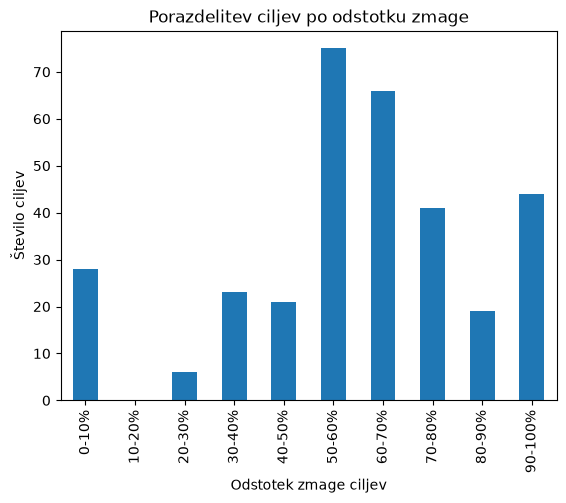

In [24]:
tenths = [0]*10

    
for _, row in goals.iterrows():
    item = row['win_ratio']
    if item == 100:
        tenths[9]+=1
    elif not pd.isna(item):
        tenths[int(item // 10)] += 1



partitions = ['0-10%','10-20%','20-30%','30-40%','40-50%','50-60%','60-70%','70-80%','80-90%','90-100%']

graph = pd.Series(tenths, index=partitions)

graph.plot(
    title='Porazdelitev ciljev po odstotku zmage',
    kind='bar',
    xlabel='Odstotek zmage ciljev',
    ylabel='Število ciljev',
)


plt.show()

# 2) Najpogosteje in najredkeje izbrani cilji

*Izbran (%)* predstavlja odstotek iger, v katerih je igralec izbral ta cilj. V tabelah so predstavljeni le cilji, ki so se v draftu pojavili vsaj petkrat.

V prvi tabeli je predstavljenih 20 ciljev z najvišjim odstotkom izbire. 

V drugi tabeli je predstavljenih 20 ciljev z najnižjim odstotkom izbire. 

In [10]:
(
goals[goals['choice'] >= 5]
.sort_values(by='draft_ratio', ascending=False)[['name','draft_ratio','win_ratio']]
.head(20)
.rename(columns={'name': 'Ime', 'draft_ratio': 'Izbran (%)', 'win_ratio': 'Zmagan (%)'})
)

,Ime,Izbran (%),Zmagan (%)
id,,,
31,Craft 100 Unique Items,100.0,100.0
261,Obtain Smooth Quartz Stairs,93.0,89.0
58,Eat 20 Unique Food,92.0,64.0
158,Obtain 10 Advancements,91.0,70.0
80,Fill Inventory with unique items,89.0,89.0
113,Kill Red Sheep,88.0,62.0
160,Obtain 30 Advancements,86.0,100.0
204,Obtain Bell,83.0,55.0
30,Craft 50 Unique Items,83.0,88.0


In [11]:
(
goals[goals['choice'] >= 5]
.sort_values(by='draft_ratio', ascending=True)[['name','draft_ratio','win_ratio']]
.head(20)
.rename(columns={'name': 'Ime', 'draft_ratio': 'Izbran (%)', 'win_ratio': 'Zmagan (%)'})
)

,Ime,Izbran (%),Zmagan (%)
id,,,
6,Breed Camels,0.0,100.0
9,Breed Foxes,0.0,NaN
48,Die to Pufferfish,0.0,100.0
37,Die by Freezing,0.0,0.0
44,Die to Falling Stalactite,0.0,67.0
47,Die to Polar Bear,0.0,50.0
103,Kill all Raid Mobs,0.0,NaN
166,Obtain 64 Gray Concrete,0.0,50.0
288,Tame a Parrot,0.0,0.0


Spodnjui tortni diagram:
1. Z **zeleno** prikazuje cilje, ki jih igralec zelo pogosto izbira - v vsaj 80% draftov
2. Z **modro** prikazuje cilje, ki jih igralec zelo redko izbira - v manj kot 20% draftov
3. Z **oranžno** prikazuje ostale cilje.

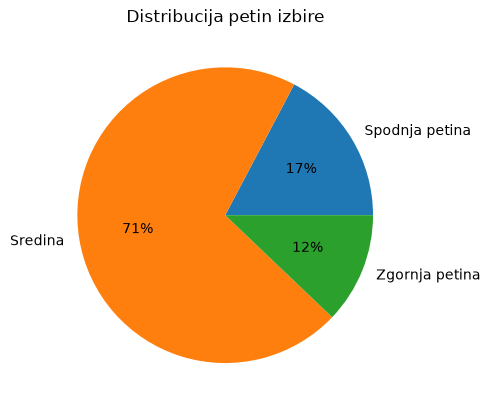

In [12]:

count_low = (goals['draft_ratio'] <= 20).sum()
count_high = (goals['draft_ratio'] >= 80).sum()
count_mid = ((goals['draft_ratio']>20) & (goals['draft_ratio']<80)).sum()
count_sum=count_low+count_high+count_mid


data = pd.DataFrame({
    'Name': ['Spodnja petina'] + ['Sredina'] + ['Zgornja petina'] ,
    'Percentage': [
        count_low,
        count_mid,
        count_high,
    ],
})


data.groupby('Name')['Percentage'].sum().plot(
    kind='pie',
    autopct='%1.0f%%',
    ylabel='',
    legend=False,
    title='Distribucija petin izbire',
)

plt.show()

# 3) Učinkovitost izbire
Rečemo, da igralec cilj izbira *učinkovito*, če ga tako izbira kot tudi opravlja zelo pogosto.

*Učinkovitost* cilja definiramo kot vsoto odstotka izbire in odstotka zmag.

V tabeli je predstavljenih 20 ciljev z najvišjo učinkovitostjo izbire.

In [13]:
goals['draft_efficiency'] = (goals['draft_ratio'] + goals['win_ratio'])

(
goals[goals['draft_efficiency'].notnull() & (goals['appeared']>= 3)]
.sort_values(by=['draft_efficiency'], ascending=[False])
)

(
goals[goals['appeared']>= 5]
.sort_values(by='draft_efficiency', ascending=False)[['name','draft_ratio','win_ratio', 'draft_efficiency']]
.head(20)
.rename(columns={'name': 'Ime', 'draft_ratio': 'Izbran (%)', 'win_ratio': 'Zmagan (%)', 'draft_efficiency': 'Učinkovitost izbire (%)'})
)

,Ime,Izbran (%),Zmagan (%),Učinkovitost izbire (%)
id,,,,
31,Craft 100 Unique Items,100.0,100.0,200.0
160,Obtain 30 Advancements,86.0,100.0,186.0
261,Obtain Smooth Quartz Stairs,93.0,89.0,182.0
80,Fill Inventory with unique items,89.0,89.0,178.0
72,Enter The End,76.0,100.0,176.0
21,Brew a Potion of Swiftness,72.0,100.0,172.0
30,Craft 50 Unique Items,83.0,88.0,171.0
11,Breed Goats,67.0,100.0,167.0
151,Obtain 3 types of Horse Armor,79.0,84.0,163.0


V naslednjem grafu je predstavljena odvisnost odstotka izbire in odstotka zmag. 

Na x-osi so razporejeni cilji, urejeni po odstotku izbire. Z oranžnimi točkami je predstavljen njihov odstotek zmag.

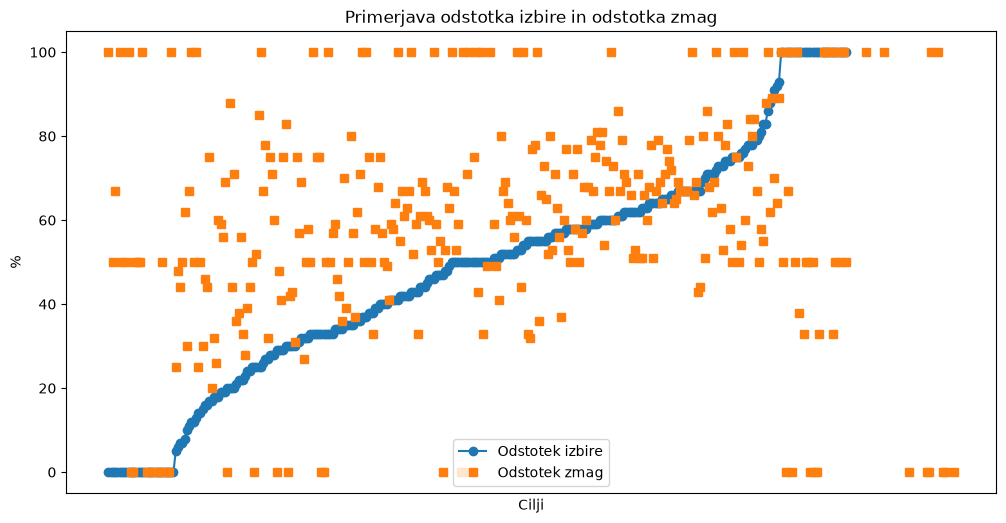

In [18]:

draft_sorted = goals.sort_values(by='draft_ratio').reset_index(drop=True)
x_axis = draft_sorted.index
plt.figure(figsize=(12, 6))

plt.plot(
    x_axis,
    draft_sorted['draft_ratio'],
    marker='o',
    color='tab:blue',
    label='Odstotek izbire',
)

plt.plot(
    x_axis,
    draft_sorted['win_ratio'],
    marker='s',
    linestyle='None',
    color='tab:orange',
    label='Odstotek zmag',
)
plt.xticks([])
plt.title('Primerjava odstotka izbire in odstotka zmag')
plt.xlabel('Cilji')
plt.ylabel('%')
plt.legend()
plt.show()

# 4) Najredkeje in najpogosteje opravljeni cilji

Opravljen (%) predstavlja odstotek vseh iger, v katerih je bil določen cilj opravljen s strani kateregakoli igralca.

V spodnjih tabelah so predstavljeni cilji z najvišjim in najnižjim odstotkom opravljenosti. Prikazani so le cilji, ki so se pojavili vsaj petkrat.

In [19]:
goals['completion_ratio'] = round(100*(goals['completed'] + goals['lost']) / goals['appeared'])

(
goals[goals['appeared']>= 5]
.sort_values(by='completion_ratio', ascending=False)[['name','win_ratio','draft_ratio','completion_ratio']]
.head(30)
.rename(columns={'name': 'Ime', 'win_ratio': 'Zmagan (%)', 'draft_ratio': 'Izbran (%)', 'completion_ratio': 'Opravljen (%)'})
)

,Ime,Zmagan (%),Izbran (%),Opravljen (%)
id,,,,
7,Breed Chickens,55.0,47.0,100.0
8,Breed Cows,58.0,81.0,100.0
34,Die by Drowning,26.0,18.0,100.0
29,Craft 20 Unique Items,78.0,55.0,100.0
33,Decorate Shield with Banner,53.0,58.0,100.0
80,Fill Inventory with unique items,89.0,89.0,100.0
79,Fill Composter and get Bone Meal,60.0,63.0,100.0
75,Fill a Decorated Pot,49.0,40.0,100.0
77,Fill Campfire with 4 Food Items,59.0,43.0,100.0


In [20]:
(
goals[goals['appeared']>= 5]
.sort_values(by='completion_ratio', ascending=True)[['name','win_ratio','draft_ratio','completion_ratio']]
.head(20)
.rename(columns={'name': 'Ime', 'win_ratio': 'Zmagan (%)', 'draft_ratio': 'Izbran (%)', 'completion_ratio': 'Opravljen (%)'})
)

,Ime,Zmagan (%),Izbran (%),Opravljen (%)
id,,,,
306,Wear a Chain Armor Piece,NaN,62.0,0.0
373,Wear Full Diamond Armor,100.0,37.0,5.0
4,Breed 8 Unique Animals,0.0,47.0,8.0
271,Put Wolf Armor on Wolf,0.0,30.0,9.0
35,Die by falling in Void,100.0,41.0,17.0
92,Get on Nether Roof,88.0,20.0,21.0
264,Obtain Suspicious Sand/Gravel,50.0,25.0,22.0
131,Leash 8 unique Mobs at once,75.0,59.0,23.0
18,Brew a Potion of Healing,67.0,42.0,25.0


# 5) Analiza igralca Feinberg

**1)**
Opazimo, da ima kar na 11 ciljih 100% odstotek zmag. Kljub temu, da gre za najboljšega igralca, je to presenetljivo visoka konsistentnost. To pojasnjuje dejstvo, da so vsi ti cilji precej zahtevni in so običajno opravljeni precej pozno v igri.

Iz druge tabele in grafa lahko razberemo, da ima igralec pri skoraj vseh ciljih odstotek zmag višji od 25%. Graf porazdelitve odstotka zmage je močno zamaknjen v desno, kar potrjuje, da je igralec res sodi med najboljše. Kot bi lahko pričakovali, ima največ ciljev odstotek zmag med 50% in 70%.



**2)**
Zanimivo je, da obstaja le en cilj, ki ga igralec izbere vedno. Večina ciljev ima odstotek izbire 80% ali manj. Po drugi strani pa obstaja kar 11 ciljev, ki jih ne izbere nikoli, ter še nekaj ciljev z zelo nizkom odstotkom izbire.

To potrjuje tudi tortni diagram, iz katerega razberemo, da je več ciljev, ki se jim izogiba, kot pa takih, ki jih itbere skoraj vedno. Poleg tega lahko opazimo, da več kot 70% ciljev ne sodi niti v zgornjo, niti v spodnjo petino.



**3)**
Edini cilj s 100% odstotkom izbire ima prav tako 100% odstotek zmag. Presenetljivo imajo skoraj vsi cilji učinkovitost manjšo od 160%, kljub zelo visokim odstotkom zmag  ciljev. Igralec se torej nekaterim ciljem izogiba kljub zelo visokemu odstotku zmage.

Na naslednjem grafu ni moč opaziti nobene korelacije med odstotkom zmag in odstotkom izbire. Vidimo lahko, da je veliko ciljev z odstotkom zmage 0% ali 100% porazdeljenih po celotnem spektru odstotka izbire, toda ker so prikazani cilji niso filtrirani, se je se je kateri od njih morda pojavil le v eni ali dveh igrah.



**4)**
V prvi tabeli so prikazani cilji, ki so opravljeni praktično v vseh igrah. Razberemo lahko, da so njihovi odstotki zmag v primerjavi s povprečjem precej nizki - veliko jih sega okoli 50%.

Po drugi strani so odstotki zmage najmanj opravljenih ciljev zelo visoki, kar ponovno potrjuje, da je igraloec najbojši v dolgigh in težkih ciljih, ki niso opravljeni v vsaki igri.
